In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gauravrawat99/demand-forecasting-1/demand_forecasting.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/kaggle/input/datasets/gauravrawat99/demand-forecasting-1/demand_forecasting.csv")
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [4]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
# df1=df.set_index('Date', inplace=False)
# df1

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object    

In [6]:
df.isna().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(0)

### Feature Engineering

In [8]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df["Weekday"] = df["Date"].dt.day_name()
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64,2024,1,30,Tuesday
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137,2024,1,30,Tuesday
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68,2024,1,30,Tuesday
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84,2024,1,30,Tuesday


In [9]:
df['Discounted Price'] = df['Price'] * (1 - df['Discount'] / 100)
df['Sell through rate'] = df['Units Sold'] / df["Inventory Level"]

In [10]:
df.groupby("Category")['Demand'].agg(['mean', 'sum', 'std']).sort_values(by="sum", ascending=False)

,mean,sum,std
Category,,,
Groceries,120.976447,3677684,48.362730
Clothing,112.619737,1369456,41.022968
Furniture,73.581140,1006590,32.336141
Toys,92.606955,985338,46.170390
Electronics,97.482018,889036,40.557859


In [11]:
df.groupby(['Region', "Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [12]:
df.groupby("Promotion")['Demand'].mean() #Tells about how promotion affects demand

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

In [13]:
pt_month = pd.pivot_table(df, values='Demand', index='Month', columns='Category', aggfunc='mean')
pt_month

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


In [14]:
from scipy.stats import skew
skewness=df.select_dtypes(include=['int64', 'float64']).skew()
print(skewness)

Inventory Level       1.591938
Units Sold            0.790429
Units Ordered         2.515878
Price                 0.485025
Discount              0.643149
Promotion             0.728160
Competitor Pricing    0.549003
Epidemic              1.500030
Demand                0.607778
Discounted Price      0.587976
Sell through rate     0.671836
dtype: float64


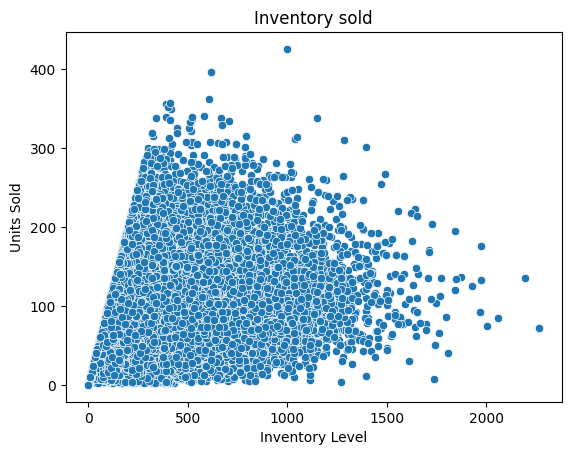

In [15]:
sns.scatterplot(data=df, x='Inventory Level', y = "Units Sold")
plt.title("Inventory sold")
plt.show()

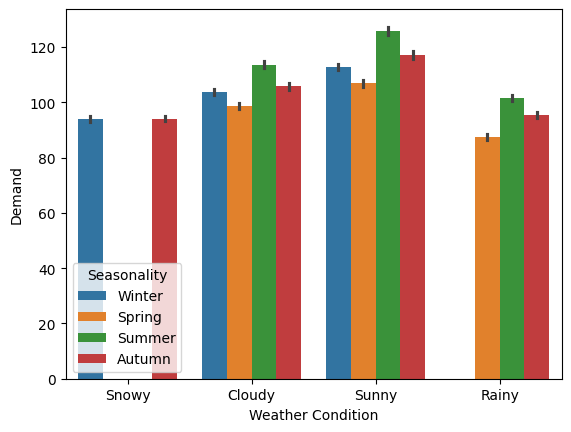

In [22]:
sns.barplot(data=df, x="Weather Condition", y='Demand',hue='Seasonality')
plt.xlabel('Weather Condition')
plt.ylabel('Demand')
plt.show()

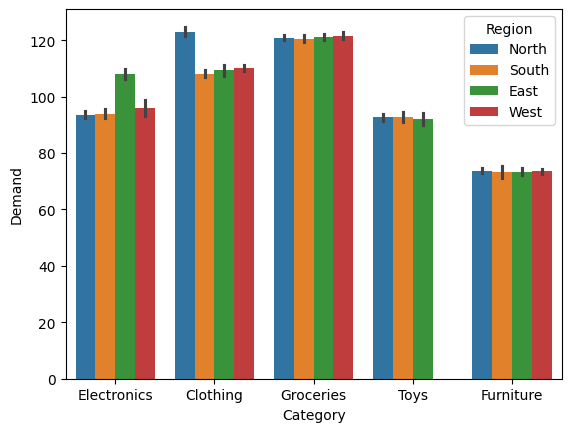

In [26]:
sns.barplot(data=df, x='Category', y='Demand', hue='Region')
plt.xlabel("Category")
plt.ylabel('Demand')
plt.show()

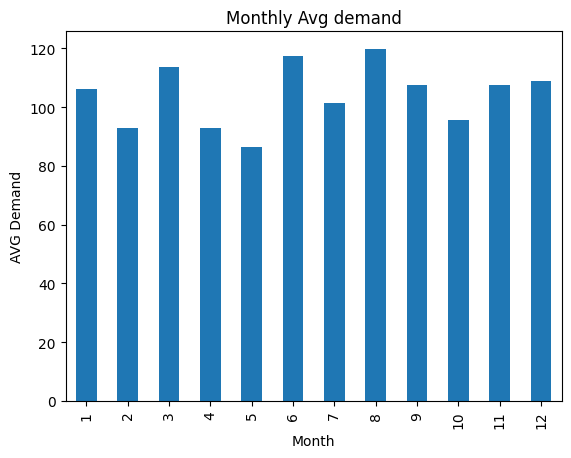

In [44]:
monthly_demand = df.groupby('Month')['Demand'].mean()
monthly_demand
#sns.barplot(data=df, x='Month', y='Demand')
monthly_demand.plot(kind='bar')
plt.xlabel("Month")
plt.ylabel('AVG Demand')
plt.title('Monthly Avg demand')
plt.show()

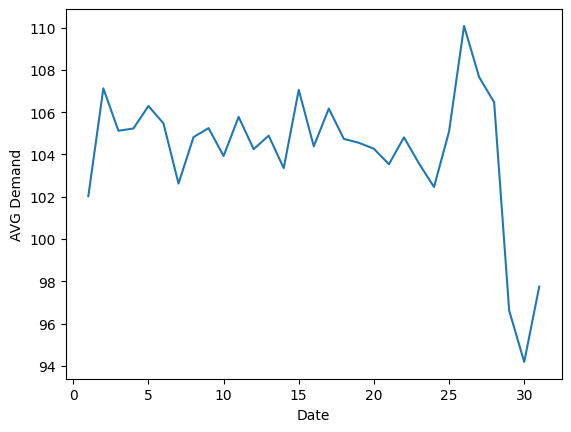

In [38]:
#Day performance by AVG Demand
daily_demand=df.groupby('Day')['Demand'].mean()
daily_demand.plot()
plt.xlabel('Date')
plt.ylabel('AVG Demand')
plt.show()

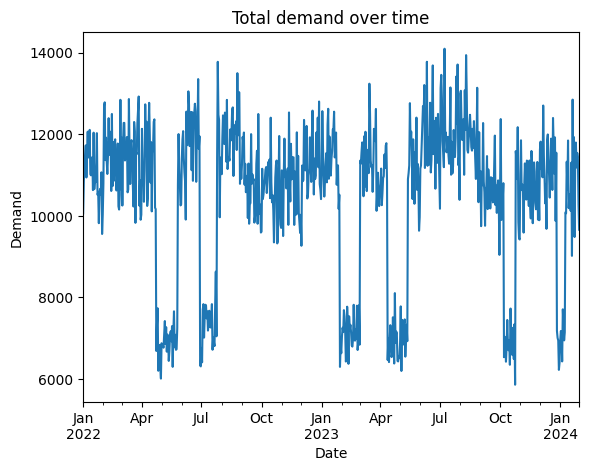

In [40]:
date_demand=df.groupby('Date')['Demand'].sum()
date_demand.plot()
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('Total demand over time')
plt.show()

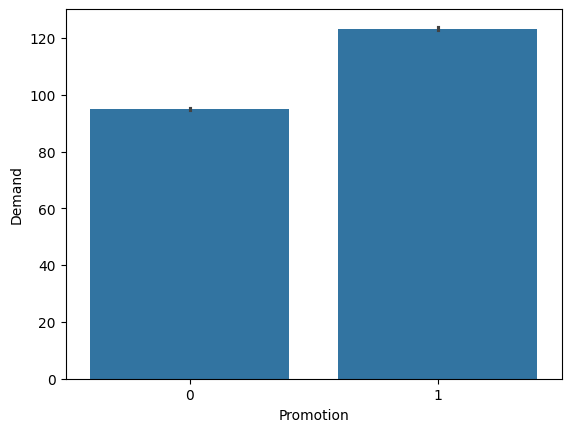

In [43]:
sns.barplot(data=df, x='Promotion', y='Demand')
plt.xlabel("Promotion")
plt.ylabel("Demand")
plt.show()

## Model Training

In [53]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price,Sell through rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,32.23,Winter,0,64,2024,1,30,Tuesday,28.310,0.270386
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,40.73,Winter,0,137,2024,1,30,Tuesday,40.774,0.839416
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,19.41,Winter,0,68,2024,1,30,Tuesday,16.029,0.223350
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,143.71,Winter,0,84,2024,1,30,Tuesday,151.720,0.464000


In [113]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# X=df.drop('Demand', axis=1)
# y=df['Demand']

In [79]:
# X

In [80]:
# y

In [70]:
# print("Original data shape:", df.shape)
# print("Original data columns: ", df.columns)

# df_dummy_data=pd.get_dummies(df)
# print("df_dummy_data shape: ", df_dummy_data.shape)
# print('df_dummy_data columns: ', df_dummy_data.columns)
# # df_dummy_data.info()

In [83]:
#Applying Onehotencoding to data
cat_cols=df.select_dtypes(include='object').columns
# print(cat_cols)
encoder=OneHotEncoder(sparse_output=False)
encoded_cols=encoder.fit_transform(df[cat_cols])

#Get them as dataframe
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(cat_cols))
df_encoded=pd.concat([df,encoded_df], axis=1)
df_encoded=df_encoded.drop(cat_cols, axis=1)
print("Encoded emp data: ", df_encoded)
print("Encoded columns list: ", df_encoded.columns)

Encoded emp data:              Date  Inventory Level  Units Sold  Units Ordered   Price  \
0     2022-01-01              195         102            252   72.72   
1     2022-01-01              117         117            249   80.16   
2     2022-01-01              247         114            612   62.94   
3     2022-01-01              139          45            102   87.63   
4     2022-01-01              152          65            271   54.41   
...          ...              ...         ...            ...     ...   
75995 2024-01-30              233          63              0   29.80   
75996 2024-01-30              137         115            141   42.92   
75997 2024-01-30              197          44              0   17.81   
75998 2024-01-30              125          58              0  151.72   
75999 2024-01-30              126          63             59   25.78   

       Discount  Promotion  Competitor Pricing  Epidemic  Demand  ...  \
0             5          0               85

In [94]:
X=df_encoded.drop(['Date','Demand'], axis=1)
y=df_encoded['Demand']

In [99]:
X = X.astype({col: "float32" for col in X.select_dtypes(include=["float64"]).columns})

In [100]:
X = X.astype({col: "int32" for col in X.select_dtypes(include=["int64"]).columns})

In [101]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 62 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Inventory Level           76000 non-null  int32  
 1   Units Sold                76000 non-null  int32  
 2   Units Ordered             76000 non-null  int32  
 3   Price                     76000 non-null  float32
 4   Discount                  76000 non-null  int32  
 5   Promotion                 76000 non-null  int32  
 6   Competitor Pricing        76000 non-null  float32
 7   Epidemic                  76000 non-null  int32  
 8   Year                      76000 non-null  int32  
 9   Month                     76000 non-null  int32  
 10  Day                       76000 non-null  int32  
 11  Discounted Price          76000 non-null  float32
 12  Sell through rate         75594 non-null  float32
 13  Store ID_S001             76000 non-null  float32
 14  Store 

In [102]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 76000 entries, 0 to 75999
Series name: Demand
Non-Null Count  Dtype
--------------  -----
76000 non-null  int64
dtypes: int64(1)
memory usage: 593.9 KB


In [105]:
#Finding imp Features using RFE
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

select=RFE(RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1, max_depth=5), n_features_to_select=40).fit(X_train, y_train)

X_train_rfe=select.transform(X_train)
X_test_rfe=select.transform(X_test)
print("Selected Features: ", select.support_)

Selected Features:  [ True  True  True False  True  True False  True False False False False
  True False False False False False False False False False False False
 False False False False False  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True]


In [111]:
#Getting names of selected columns
selected_cols=X_train.columns[select.support_].tolist()
print("Selected Columns are: ", selected_cols)
print("Length of selected columns: ",len(selected_cols))


Selected Columns are:  ['Inventory Level', 'Units Sold', 'Units Ordered', 'Discount', 'Promotion', 'Epidemic', 'Sell through rate', 'Product ID_P0012', 'Product ID_P0013', 'Product ID_P0014', 'Product ID_P0015', 'Product ID_P0016', 'Product ID_P0017', 'Product ID_P0018', 'Product ID_P0019', 'Product ID_P0020', 'Category_Clothing', 'Category_Electronics', 'Category_Furniture', 'Category_Groceries', 'Category_Toys', 'Region_East', 'Region_North', 'Region_South', 'Region_West', 'Weather Condition_Cloudy', 'Weather Condition_Rainy', 'Weather Condition_Snowy', 'Weather Condition_Sunny', 'Seasonality_Autumn', 'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter', 'Weekday_Friday', 'Weekday_Monday', 'Weekday_Saturday', 'Weekday_Sunday', 'Weekday_Thursday', 'Weekday_Tuesday', 'Weekday_Wednesday']
Length of selected columns:  40


In [114]:
#Training XGB now now on selected features
from xgboost import XGBRegressor
xgb=XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, n_jobs=-1, random_state=0).fit(X_train_rfe, y_train)

print("Predicted values: ", xgb.predict(X_test_rfe))
print("Training accuracy: ", xgb.score(X_train_rfe, y_train))
print("Test accuracy: ", xgb.score(X_test_rfe, y_test))

Predicted values:  [106.6938    89.70314   40.651226 ...  29.852606  22.505278 132.50906 ]
Training accuracy:  0.8681341409683228
Test accuracy:  0.8627530336380005


Selected Features are:
  Units Sold                  0.645496
Sell through rate           0.104315
Units Ordered               0.045871
Promotion                   0.027524
Category_Furniture          0.022473
Epidemic                    0.020996
Category_Groceries          0.019962
Seasonality_Summer          0.014444
Weather Condition_Sunny     0.012409
Category_Clothing           0.010523
Seasonality_Winter          0.008014
Weather Condition_Cloudy    0.007056
Category_Toys               0.006151
Region_South                0.004504
Inventory Level             0.004220
Weather Condition_Snowy     0.003911
Product ID_P0016            0.003817
Seasonality_Spring          0.003759
Product ID_P0018            0.003421
Region_North                0.003394
Category_Electronics        0.003292
Weather Condition_Rainy     0.003271
Product ID_P0012            0.003263
Region_East                 0.002682
Seasonality_Autumn          0.002667
Product ID_P0019            0.002256
Product ID_P0

<Axes: >

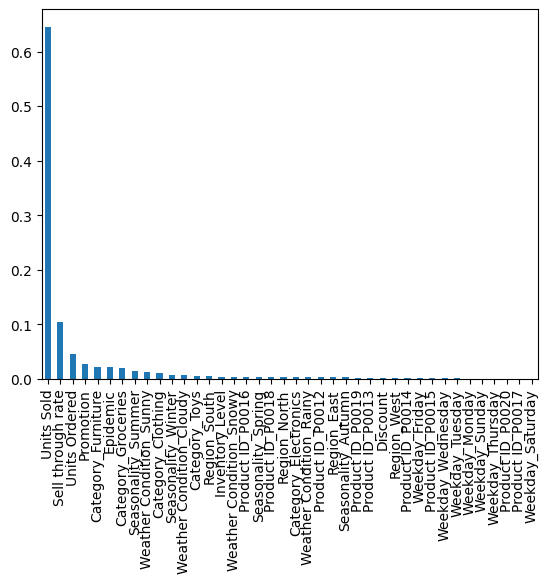

In [122]:
#Trained Feature Importance
imp_features= xgb.feature_importances_
imp_series=pd.Series(imp_features, index=selected_cols, name='importance').sort_values(ascending=False)
# print("Important features are: ", imp_features, index=X_train.columns)
print("Selected Features are:\n ", imp_series)
#Plot
imp_series.plot(kind='bar')

In [130]:
#Metrices
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred=xgb.predict(X_test_rfe)

mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mean_squared_error(y_test, y_pred))
mae=mean_absolute_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)

print("Mean squared error: ", mse)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("R2 score: ", r2)

Mean squared error:  303.112060546875
RMSE:  17.410113743076895
MAE:  13.322970390319824
R2 score:  0.8627530336380005


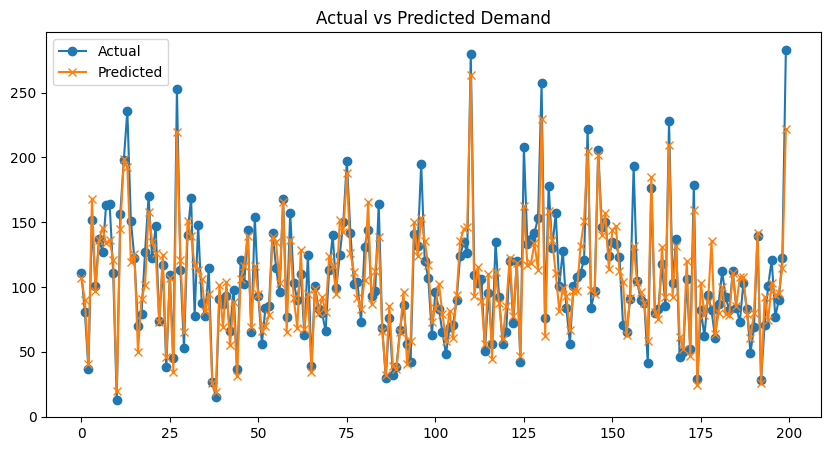

In [131]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label="Actual", marker='o')
plt.plot(y_pred[:200], label="Predicted", marker='x')
plt.legend()
plt.title("Actual vs Predicted Demand")
plt.show()


#### Future work: Adding holidays or imp days as features, Bayesian XGBoost hyperparamter tuning, Rolling window stats